## Personalised Modelling: Human Movement

This notebook tests whether a small amount of participant-specific data improves movement classification.

Frame-level observations are aggregated into trial-level features. Evaluation uses leave-one-participant-out splitting, with a small calibration set from the held-out participant.

The personalised model is compared with the generic baseline on the same unseen target trials.

Two feature representations are evaluated:

Full representation: 36 features using mean, standard deviation, minimum, and maximum.
Reduced representation: 18 features using mean and standard deviation only.

The reduced representation was selected based on the feature ablation experiment in the baseline notebook, where it achieved slightly higher cross-participant performance than the full representation.

## Experimental Setup

The experiment uses the same trial-level representation, evaluation framework, and Logistic Regression model as the baseline.

For each participant:

- train the generic model on the other participant
- reserve 2 trials per movement class from the target participant for calibration
- add these calibration trials to the generic training data
- evaluate both models on the remaining target trials

This gives:

- 10 calibration trials per participant
- 40 unseen test trials per participant
- 2 calibration trials per movement class

The comparison is performed separately for the full and reduced feature representations.

This allows the effect of participant-specific calibration to be evaluated independently of the feature representation.

In [1]:
# Imports

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

In [2]:
DATA_DIR = Path("../data/movement")

IDENTIFIER_COLUMNS = [
    "participant_id",
    "session_id",
    "trial_id",
    "movement_label",
]

FEATURE_COLUMNS = [
    "shoulder_width",
    "head_offset_x",
    "head_offset_y",
    "torso_dx",
    "torso_dy",
    "movement_speed",
    "head_offset_z",
    "torso_dz",
    "movement_speed_3d",
]

TARGET_COLUMN = "movement_label"

GROUP_COLUMNS = [
    "participant_id",
    "session_id",
    "trial_id",
    "movement_label",
]

AGGREGATION_FUNCTIONS = [
    "mean",
    "std",
    "min",
    "max",
]

CALIBRATION_TRIALS_PER_CLASS = 2

REDUCED_STATISTICS = [
    "mean",
    "std",
]

In [3]:
# Load dataset

files = sorted(DATA_DIR.glob("P*_S*.csv"))

if not files:
    raise FileNotFoundError(
        f"No participant/session CSV files found in {DATA_DIR.resolve()}"
    )

frames = [pd.read_csv(file) for file in files]

df = pd.concat(
    frames,
    ignore_index=True,
)

print(f"Files loaded: {len(files)}")
print(f"Dataset shape: {df.shape}")

Files loaded: 4
Dataset shape: (5555, 14)


In [4]:
display(
    df[
        [
            "participant_id",
            "session_id",
            "trial_id",
            "movement_label",
        ]
    ].head()
)

,participant_id,session_id,trial_id,movement_label
0,P01,S01,1,neutral
1,P01,S01,1,neutral
2,P01,S01,1,neutral
3,P01,S01,1,neutral
4,P01,S01,1,neutral


In [5]:
# Trial-level representation

trial_features = (
    df.groupby(GROUP_COLUMNS)[FEATURE_COLUMNS]
    .agg(AGGREGATION_FUNCTIONS)
)

trial_features.columns = [
    f"{feature}_{stat}"
    for feature, stat in trial_features.columns
]

trial_features = trial_features.reset_index()

trial_feature_columns = [
    column
    for column in trial_features.columns
    if column not in GROUP_COLUMNS
]

print(f"Trials: {len(trial_features)}")
print(f"Modelling features: {len(trial_feature_columns)}")

display(trial_features.head())

Trials: 100
Modelling features: 36


,participant_id,session_id,trial_id,movement_label,shoulder_width_mean,shoulder_width_std,shoulder_width_min,shoulder_width_max,head_offset_x_mean,head_offset_x_std,head_offset_x_min,head_offset_x_max,head_offset_y_mean,head_offset_y_std,head_offset_y_min,head_offset_y_max,torso_dx_mean,torso_dx_std,torso_dx_min,torso_dx_max,torso_dy_mean,torso_dy_std,torso_dy_min,torso_dy_max,movement_speed_mean,movement_speed_std,movement_speed_min,movement_speed_max,head_offset_z_mean,head_offset_z_std,head_offset_z_min,head_offset_z_max,torso_dz_mean,torso_dz_std,torso_dz_min,torso_dz_max,movement_speed_3d_mean,movement_speed_3d_std,movement_speed_3d_min,movement_speed_3d_max
0,P01,S01,1,neutral,0.333478,0.001824,0.332019,0.338862,0.027531,0.005356,0.017358,0.040083,-0.892127,0.013139,-0.910118,-0.855146,-0.000470,0.001788,-0.008693,0.002234,0.002372,0.003835,-0.001458,0.013246,0.043863,0.058488,0.0,0.250578,-0.634818,0.006986,-0.648257,-0.621308,0.000829,0.009888,-0.024675,0.040932,0.108272,0.103189,0.0,0.561603
1,P01,S01,2,neutral,0.335893,0.000788,0.334116,0.337427,0.037758,0.003797,0.029882,0.046012,-1.033394,0.012667,-1.057834,-1.009514,-0.000008,0.000514,-0.001442,0.000816,0.000202,0.001966,-0.005952,0.007358,0.021114,0.022412,0.0,0.104929,-0.535309,0.022043,-0.575978,-0.467373,0.001613,0.029885,-0.068112,0.091241,0.384039,0.378843,0.0,2.103741
2,P01,S01,3,neutral,0.333582,0.001072,0.332415,0.337141,0.029839,0.004679,0.024641,0.045967,-0.960535,0.008964,-0.983787,-0.942649,-0.000016,0.000351,-0.001334,0.000783,-0.000060,0.001102,-0.004091,0.003732,0.013270,0.013942,0.0,0.082244,-0.591936,0.005654,-0.603133,-0.578602,-0.000329,0.007374,-0.029549,0.020634,0.088512,0.085349,0.0,0.383539
3,P01,S01,4,neutral,0.335082,0.000511,0.334168,0.336226,0.041286,0.003732,0.033055,0.050552,-0.931393,0.009354,-0.950397,-0.910570,0.000078,0.000487,-0.000853,0.001733,0.000136,0.001519,-0.004978,0.004061,0.016416,0.015690,0.0,0.077571,-0.604767,0.008319,-0.624559,-0.583149,-0.000259,0.005510,-0.012487,0.010232,0.086544,0.055718,0.0,0.244262
4,P01,S01,5,neutral,0.336775,0.000574,0.336090,0.338671,0.042007,0.003948,0.033847,0.048941,-0.916819,0.009203,-0.934231,-0.895239,0.000017,0.000464,-0.001293,0.001116,0.000445,0.002508,-0.004032,0.011581,0.028936,0.028535,0.0,0.144931,-0.602010,0.006255,-0.622974,-0.591185,-0.000800,0.010731,-0.037590,0.024136,0.133506,0.117260,0.0,0.523861


In [6]:
# Trial-level dataset overview


print(
    f"Participants: "
    f"{trial_features['participant_id'].nunique()}"
)

print(
    f"Sessions: "
    f"{len(trial_features[['participant_id', 'session_id']].drop_duplicates())}"
)

print(
    f"Trials: "
    f"{len(trial_features)}"
)

print(
    f"Movement classes: "
    f"{trial_features[TARGET_COLUMN].nunique()}"
)

display(
    trial_features[TARGET_COLUMN]
    .value_counts()
    .sort_index()
)

Participants: 2
Sessions: 4
Trials: 100
Movement classes: 5


movement_label
lean_forward    20
lean_left       20
lean_right      20
neutral         20
raise_arms      20
Name: count, dtype: int64

In [7]:
# Participant evaluation

participants = sorted(
    trial_features["participant_id"].unique()
)

print("Participants:")

for participant in participants:
    print(f"  - {participant}")

Participants:
  - P01
  - P02


In [8]:
# Model

# The same Logistic Regression pipeline used in the baseline is used here.
# Standardisation is fitted only on the training data within each participant evaluation.

def create_model():
    return Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            (
                "classifier",
                LogisticRegression(
                    max_iter=2000,
                    random_state=42,
                ),
            ),
        ]
    )

In [9]:
# Prepare evaluation data 

# For each target participant, 2 trials per movement class are selected for calibration.
# The first two trials of each class according to the existing trial ordering are used.
# The remaining 40 trials form the completely unseen test set.
# The same calibration and test partitions are used for both feature representations.

calibration_sets = {}
test_sets = {}

for participant in participants:

    participant_data = trial_features[
        trial_features["participant_id"] == participant
    ].copy()

    calibration_indices = []

    for movement in sorted(
        participant_data[TARGET_COLUMN].unique()
    ):

        movement_indices = (
            participant_data[
                participant_data[TARGET_COLUMN] == movement
            ]
            .index
            .tolist()
        )

        calibration_indices.extend(
            movement_indices[:CALIBRATION_TRIALS_PER_CLASS]
        )

    calibration_indices = set(calibration_indices)

    calibration_sets[participant] = trial_features.loc[
        sorted(calibration_indices)
    ].copy()

    test_sets[participant] = participant_data.loc[
        ~participant_data.index.isin(calibration_indices)
    ].copy()

    print(
        f"{participant}: "
        f"{len(calibration_sets[participant])} calibration trials, "
        f"{len(test_sets[participant])} test trials"
    )

P01: 10 calibration trials, 40 test trials
P02: 10 calibration trials, 40 test trials


In [10]:
for participant in participants:

    print(f"\n{participant}")

    display(
        calibration_sets[participant][TARGET_COLUMN]
        .value_counts()
        .sort_index()
    )


P01


movement_label
lean_forward    2
lean_left       2
lean_right      2
neutral         2
raise_arms      2
Name: count, dtype: int64


P02


movement_label
lean_forward    2
lean_left       2
lean_right      2
neutral         2
raise_arms      2
Name: count, dtype: int64

In [11]:
# Define feature representations

full_feature_columns = trial_feature_columns

reduced_feature_columns = [
    f"{feature}_{stat}"
    for feature in FEATURE_COLUMNS
    for stat in REDUCED_STATISTICS
]

feature_sets = {
    "Full": full_feature_columns,
    "Reduced": reduced_feature_columns,
}

print(
    f"Full representation: "
    f"{len(full_feature_columns)} features"
)

print(
    f"Reduced representation: "
    f"{len(reduced_feature_columns)} features"
)

Full representation: 36 features
Reduced representation: 18 features


In [12]:
# Generic vs Personalised Evaluation

results = []

confusion_matrices = {
    "Full": {
        "Generic": {},
        "Personalised": {},
    },
    "Reduced": {
        "Generic": {},
        "Personalised": {},
    },
}

class_reports = {
    "Full": {
        "Generic": {},
        "Personalised": {},
    },
    "Reduced": {
        "Generic": {},
        "Personalised": {},
    },
}

X_all = trial_features[trial_feature_columns]
y_all = trial_features[TARGET_COLUMN]

for representation_name, feature_columns in feature_sets.items():

    for participant in participants:

        target_mask = (
            trial_features["participant_id"] == participant
        )

        generic_train_mask = ~target_mask

        calibration_data = calibration_sets[participant]
        test_data = test_sets[participant]

        X_generic_train = trial_features.loc[
            generic_train_mask,
            feature_columns,
        ]

        y_generic_train = y_all.loc[
            generic_train_mask
        ]

        X_calibration = calibration_data[
            feature_columns
        ]

        y_calibration = calibration_data[
            TARGET_COLUMN
        ]

        X_test = test_data[
            feature_columns
        ]

        y_test = test_data[
            TARGET_COLUMN
        ]

        # Generic model

        generic_model = create_model()

        generic_model.fit(
            X_generic_train,
            y_generic_train,
        )

        generic_predictions = generic_model.predict(
            X_test
        )

        # Personalised model

        personalised_model = create_model()

        X_personalised_train = pd.concat(
            [
                X_generic_train,
                X_calibration,
            ],
            axis=0,
        )

        y_personalised_train = pd.concat(
            [
                y_generic_train,
                y_calibration,
            ],
            axis=0,
        )

        personalised_model.fit(
            X_personalised_train,
            y_personalised_train,
        )

        personalised_predictions = (
            personalised_model.predict(X_test)
        )

        # Store results

        results.extend(
            [
                {
                    "representation": representation_name,
                    "test_participant": participant,
                    "model": "Generic",
                    "calibration_trials": 0,
                    "test_trials": len(X_test),
                    "features": len(feature_columns),
                    "accuracy": accuracy_score(
                        y_test,
                        generic_predictions,
                    ),
                    "balanced_accuracy": balanced_accuracy_score(
                        y_test,
                        generic_predictions,
                    ),
                    "macro_f1": f1_score(
                        y_test,
                        generic_predictions,
                        average="macro",
                    ),
                },
                {
                    "representation": representation_name,
                    "test_participant": participant,
                    "model": "Personalised",
                    "calibration_trials": len(
                        calibration_data
                    ),
                    "test_trials": len(X_test),
                    "features": len(feature_columns),
                    "accuracy": accuracy_score(
                        y_test,
                        personalised_predictions,
                    ),
                    "balanced_accuracy": balanced_accuracy_score(
                        y_test,
                        personalised_predictions,
                    ),
                    "macro_f1": f1_score(
                        y_test,
                        personalised_predictions,
                        average="macro",
                    ),
                },
            ]
        )

        # Confusion matrices

        confusion_matrices[
            representation_name
        ]["Generic"][participant] = confusion_matrix(
            y_test,
            generic_predictions,
            labels=generic_model.classes_,
        )

        confusion_matrices[
            representation_name
        ]["Personalised"][participant] = confusion_matrix(
            y_test,
            personalised_predictions,
            labels=personalised_model.classes_,
        )

        # Classification reports

        class_reports[
            representation_name
        ]["Generic"][participant] = classification_report(
            y_test,
            generic_predictions,
            output_dict=True,
            zero_division=0,
        )

        class_reports[
            representation_name
        ]["Personalised"][participant] = classification_report(
            y_test,
            personalised_predictions,
            output_dict=True,
            zero_division=0,
        )

results_df = pd.DataFrame(results)

display(
    results_df.round(3)
)

,representation,test_participant,model,calibration_trials,test_trials,features,accuracy,balanced_accuracy,macro_f1
0,Full,P01,Generic,0,40,36,0.900,0.900,0.903
1,Full,P01,Personalised,10,40,36,1.000,1.000,1.000
2,Full,P02,Generic,0,40,36,0.950,0.950,0.951
3,Full,P02,Personalised,10,40,36,0.975,0.975,0.975
4,Reduced,P01,Generic,0,40,18,0.925,0.925,0.924
5,Reduced,P01,Personalised,10,40,18,1.000,1.000,1.000
6,Reduced,P02,Generic,0,40,18,0.975,0.975,0.975
7,Reduced,P02,Personalised,10,40,18,0.975,0.975,0.975


In [13]:
# Results by participant

display(
    results_df[
        [
            "representation",
            "test_participant",
            "model",
            "features",
            "calibration_trials",
            "test_trials",
            "accuracy",
            "balanced_accuracy",
            "macro_f1",
        ]
    ].round(3)
)

,representation,test_participant,model,features,calibration_trials,test_trials,accuracy,balanced_accuracy,macro_f1
0,Full,P01,Generic,36,0,40,0.900,0.900,0.903
1,Full,P01,Personalised,36,10,40,1.000,1.000,1.000
2,Full,P02,Generic,36,0,40,0.950,0.950,0.951
3,Full,P02,Personalised,36,10,40,0.975,0.975,0.975
4,Reduced,P01,Generic,18,0,40,0.925,0.925,0.924
5,Reduced,P01,Personalised,18,10,40,1.000,1.000,1.000
6,Reduced,P02,Generic,18,0,40,0.975,0.975,0.975
7,Reduced,P02,Personalised,18,10,40,0.975,0.975,0.975


In [14]:
# Overall comparison

overall_results = (
    results_df
    .groupby(
        [
            "representation",
            "model",
        ]
    )[
        [
            "accuracy",
            "balanced_accuracy",
            "macro_f1",
        ]
    ]
    .mean()
)

display(
    overall_results.round(3)
)

accuracy  balanced_accuracy  macro_f1
representation model                                              
Full           Generic          0.925              0.925     0.927
               Personalised     0.988              0.988     0.987
Reduced        Generic          0.950              0.950     0.950
               Personalised     0.988              0.988     0.987

In [15]:
# Personalisation improvement

improvement_rows = []

for representation_name in feature_sets:

    generic_mean = overall_results.loc[
        (representation_name, "Generic")
    ]

    personalised_mean = overall_results.loc[
        (representation_name, "Personalised")
    ]

    improvement = (
        personalised_mean
        - generic_mean
    )

    for metric in [
        "accuracy",
        "balanced_accuracy",
        "macro_f1",
    ]:

        improvement_rows.append(
            {
                "representation": representation_name,
                "metric": metric,
                "generic": generic_mean[metric],
                "personalised": personalised_mean[metric],
                "improvement": improvement[metric],
            }
        )

improvement_df = pd.DataFrame(
    improvement_rows
)

display(
    improvement_df.round(3)
)

,representation,metric,generic,personalised,improvement
0,Full,accuracy,0.925,0.988,0.062
1,Full,balanced_accuracy,0.925,0.988,0.062
2,Full,macro_f1,0.927,0.987,0.060
3,Reduced,accuracy,0.950,0.988,0.038
4,Reduced,balanced_accuracy,0.950,0.988,0.038
5,Reduced,macro_f1,0.950,0.987,0.038


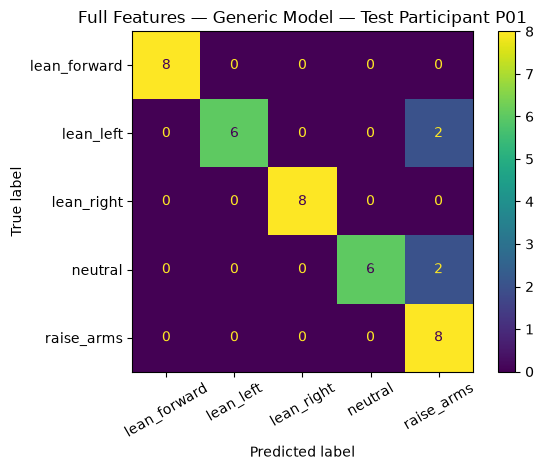

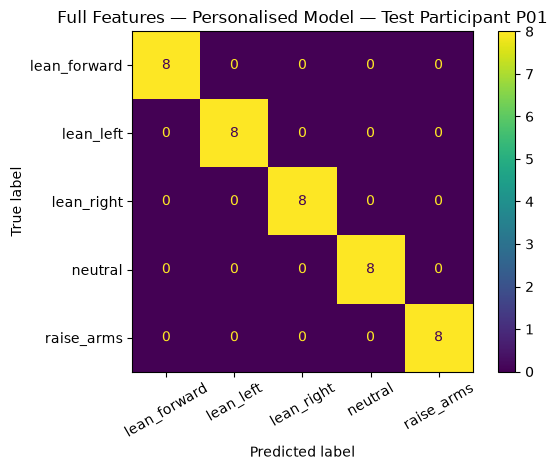

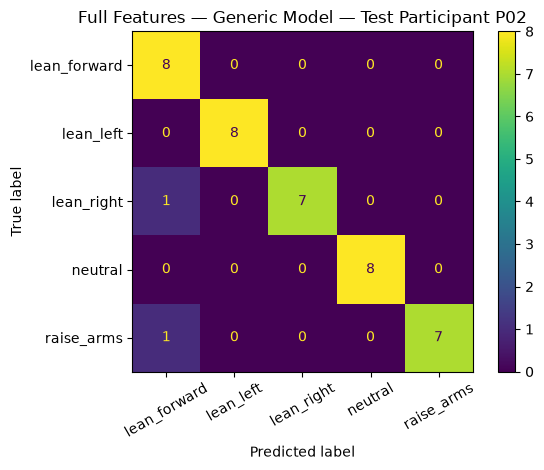

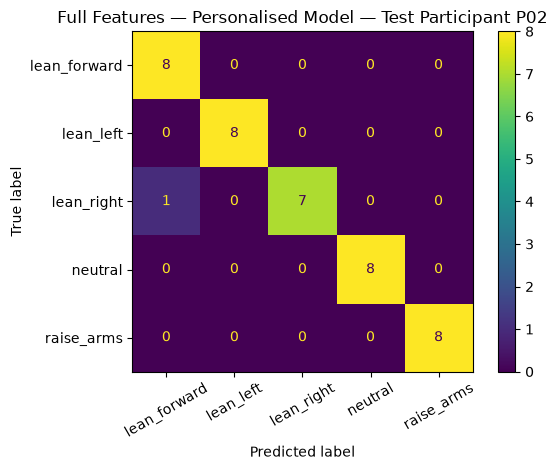

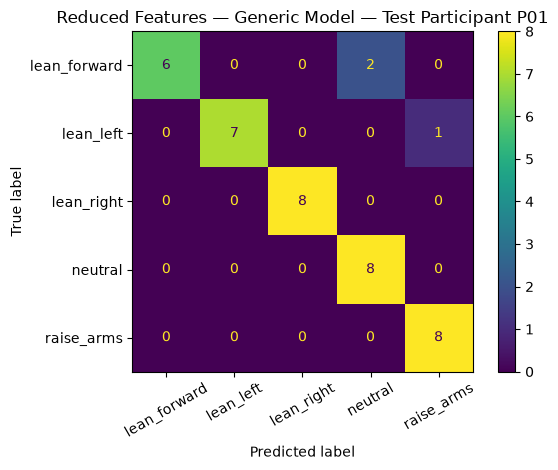

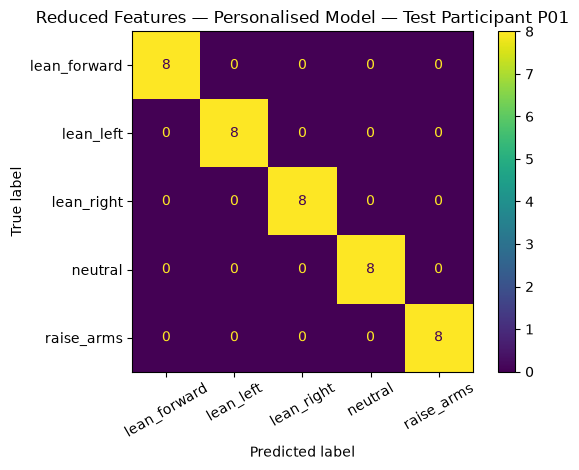

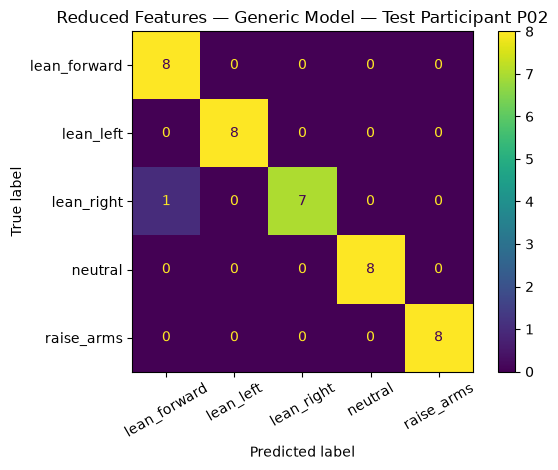

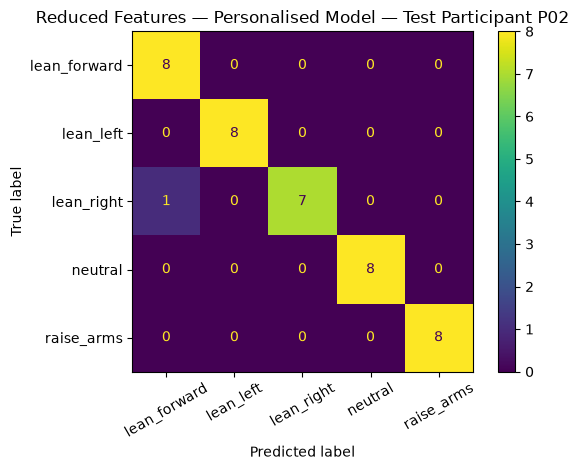

In [16]:
# Confusion matrices

for representation_name in feature_sets:

    for participant in participants:

        for model_name in [
            "Generic",
            "Personalised",
        ]:

            matrix = confusion_matrices[
                representation_name
            ][model_name][participant]

            ConfusionMatrixDisplay(
                confusion_matrix=matrix,
                display_labels=sorted(
                    trial_features[TARGET_COLUMN].unique()
                ),
            ).plot(
                xticks_rotation=30
            )

            plt.title(
                f"{representation_name} Features — "
                f"{model_name} Model — "
                f"Test Participant {participant}"
            )

            plt.tight_layout()
            plt.show()

In [17]:
# Class-level results

class_results = []

movements = sorted(
    trial_features[TARGET_COLUMN].unique()
)

for representation_name in feature_sets:

    for participant in participants:

        for model_name in [
            "Generic",
            "Personalised",
        ]:

            report = class_reports[
                representation_name
            ][model_name][participant]

            for movement in movements:

                class_results.append(
                    {
                        "representation": (
                            representation_name
                        ),
                        "test_participant": participant,
                        "model": model_name,
                        "movement": movement,
                        "precision": (
                            report[movement]["precision"]
                        ),
                        "recall": (
                            report[movement]["recall"]
                        ),
                        "f1": (
                            report[movement]["f1-score"]
                        ),
                    }
                )

class_results_df = pd.DataFrame(
    class_results
)

display(
    class_results_df.round(3)
)

,representation,test_participant,model,movement,precision,recall,f1
0,Full,P01,Generic,lean_forward,1.000,1.000,1.000
1,Full,P01,Generic,lean_left,1.000,0.750,0.857
2,Full,P01,Generic,lean_right,1.000,1.000,1.000
3,Full,P01,Generic,neutral,1.000,0.750,0.857
4,Full,P01,Generic,raise_arms,0.667,1.000,0.800
5,Full,P01,Personalised,lean_forward,1.000,1.000,1.000
6,Full,P01,Personalised,lean_left,1.000,1.000,1.000
7,Full,P01,Personalised,lean_right,1.000,1.000,1.000
8,Full,P01,Personalised,neutral,1.000,1.000,1.000
9,Full,P01,Personalised,raise_arms,1.000,1.000,1.000


## Interpretation

The personalised models are evaluated against their corresponding generic models using the same unseen target-participant trials. The experiment therefore tests whether a small amount of participant-specific calibration data can improve movement classification for a previously unseen participant.

Personalisation improved performance for both feature representations. The full representation increased from 0.925 to 0.988 balanced accuracy, while the reduced representation increased from 0.950 to 0.988. Thus, both representations reached the same overall personalised performance despite starting from different generic baselines.

The larger improvement for the full representation (+0.062) compared with the reduced representation (+0.038) is consistent with the feature ablation results from the baseline experiments. The reduced representation already provides a stronger generic model with fewer features, whereas the full representation benefits more from participant-specific calibration. This suggests that personalisation may partially compensate for the additional variability introduced by the minimum and maximum statistics.

Overall, these results provide initial evidence that a small amount of participant-specific data can improve classification of unseen movement trials. They also suggest that a simpler feature representation can achieve similar personalised performance with a stronger generic starting point and fewer features.

Because only two participants are available, however, these findings should be treated as exploratory evidence rather than evidence of generalisation to a broader population.


## Limitations

This experiment has several limitations:

* only two participants are available
* each participant contributes only two sessions
* only 2 calibration trials per movement class are used
* trial-level aggregation removes some temporal structure
* participant and recording session are linked in the current evaluation
* the small training and test sets limit the stability of performance estimates
* the calibration trials are selected deterministically rather than across multiple calibration samples

The results should therefore be interpreted as an exploratory evaluation of participant-specific adaptation rather than evidence of generalisation to a larger population.


## Next Step: Calibration Size

The next experiment can investigate how much participant-specific data is required for useful adaptation.

Possible calibration levels are:

* 0 trials per class
* 1 trial per class
* 2 trials per class
* 5 trials per class

This would allow the relationship between calibration effort and classification performance to be studied.

The calibration-size experiment should use the reduced 18-feature representation selected from the preceding feature ablation and personalisation experiments. This representation provides the stronger generic baseline while requiring half as many features as the full representation, and it reaches the same personalised performance in the current experiment.
